In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

In [2]:
feature_map = np.array([[1, 2, 3, 4, 5, 6],
                       [5, 6, 7, 8, 9, 10],
                       [9, 10, 11, 12, 13, 14],
                       [13, 14, 15, 16, 17, 18],
                       [17, 18, 19, 20, 21, 22],
                       [21, 22, 23, 24, 25, 26]])

In [3]:
def max_pooling_2d(input_map, pool_size=2):
    h, w = input_map.shape
    pool_h, pool_w = pool_size, pool_size
    out_h = h // pool_h
    out_w = w // pool_w
    
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = input_map[i*pool_h:(i+1)*pool_h, j*pool_w:(j+1)*pool_w]
            output[i, j] = np.max(region)
    return output

In [4]:
def avg_pooling_2d(input_map, pool_size=2):
    h, w = input_map.shape
    pool_h, pool_w = pool_size, pool_size
    out_h = h // pool_h
    out_w = w // pool_w
    
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = input_map[i*pool_h:(i+1)*pool_h, j*pool_w:(j+1)*pool_w]
            output[i, j] = np.mean(region)
    return output

In [5]:
max_pooled = max_pooling_2d(feature_map, pool_size=2)
avg_pooled = avg_pooling_2d(feature_map, pool_size=2)

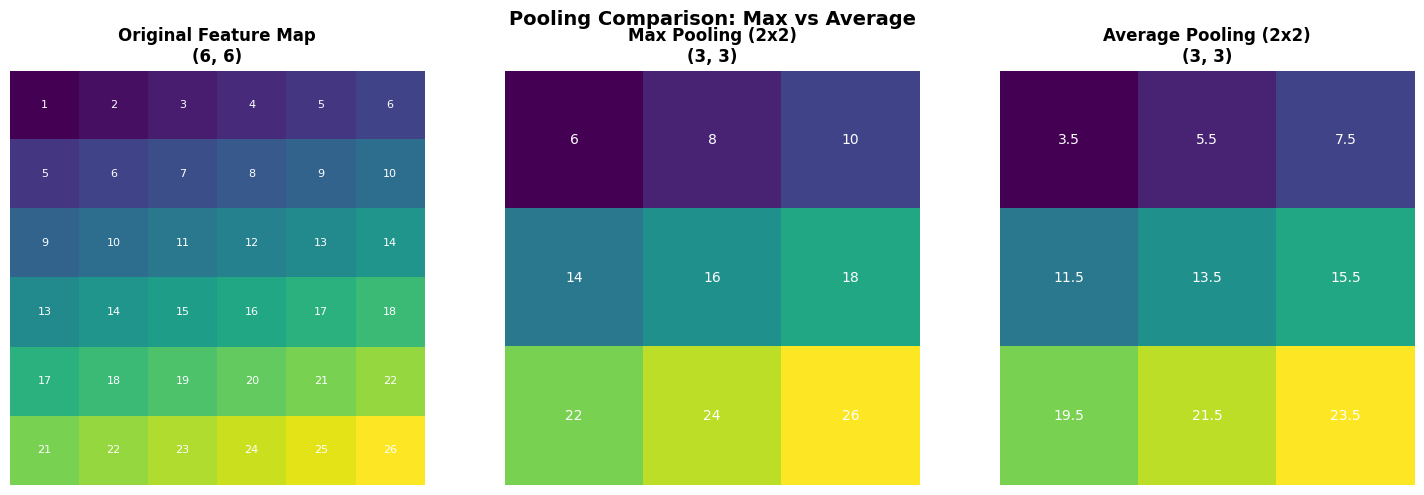

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(feature_map, cmap='viridis')
axes[0].set_title(f'Original Feature Map\n{feature_map.shape}', fontweight='bold')
axes[0].axis('off')
for i in range(feature_map.shape[0]):
    for j in range(feature_map.shape[1]):
        axes[0].text(j, i, int(feature_map[i, j]), ha='center', va='center', color='white', fontsize=8)

axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title(f'Max Pooling (2x2)\n{max_pooled.shape}', fontweight='bold')
axes[1].axis('off')
for i in range(max_pooled.shape[0]):
    for j in range(max_pooled.shape[1]):
        axes[1].text(j, i, int(max_pooled[i, j]), ha='center', va='center', color='white', fontsize=10)

axes[2].imshow(avg_pooled, cmap='viridis')
axes[2].set_title(f'Average Pooling (2x2)\n{avg_pooled.shape}', fontweight='bold')
axes[2].axis('off')
for i in range(avg_pooled.shape[0]):
    for j in range(avg_pooled.shape[1]):
        axes[2].text(j, i, f'{avg_pooled[i, j]:.1f}', ha='center', va='center', color='white', fontsize=10)

plt.suptitle('Pooling Comparison: Max vs Average', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("Original shape:", feature_map.shape)
print("After 2x2 pooling:", max_pooled.shape)
print("Reduction factor:", feature_map.size / max_pooled.size)

Original shape: (6, 6)
After 2x2 pooling: (3, 3)
Reduction factor: 4.0


**Implementing in keras**

In [10]:
from tensorflow.keras import layers
import keras

In [ ]:
# Max Pooling
max_pool = layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid')

# Average Pooling
avg_pool = layers.AveragePooling2D(pool_size=(2, 2), strides=2, padding='valid')

# Global Pooling
global_max_pool = layers.GlobalMaxPooling2D()
global_avg_pool = layers.GlobalAveragePooling2D()

In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])

model.summary()

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)

**Implementing in Pytorch**

In [12]:
import torch.nn as nn

In [ ]:
# Max Pooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

# Average Pooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

# Adaptive Pooling (outputs fixed size regardless of input)
adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))